In [29]:
# Cell 1: Import additional classifiers
from sklearn.ensemble import (
    RandomForestClassifier, 
    GradientBoostingClassifier, 
    AdaBoostClassifier,
    ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, roc_auc_score
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

In [21]:
# Cell 2: Load and prepare the data
# Load the dataset
df = pd.read_csv('parkinsons_speech_features.csv')

# Assuming the last column is the target variable (class)
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [22]:
# Cell 2: Create a dictionary of classifiers
classifiers = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42),
    'Naive Bayes': GaussianNB()
}

In [23]:
# Updated evaluation function to include training metrics
def evaluate_classifiers(X_train, X_test, y_train, y_test, classifiers):
    results = {}
    
    for name, clf in classifiers.items():
        print(f"\n{'='*50}")
        print(f"Training {name}...")
        
        # Train the classifier
        clf.fit(X_train, y_train)
        
        # Training metrics
        y_train_pred = clf.predict(X_train)
        train_accuracy = accuracy_score(y_train, y_train_pred)
        
        try:
            y_train_prob = clf.predict_proba(X_train)
            train_auc = roc_auc_score(y_train, y_train_prob[:, 1])
        except:
            train_auc = None
            
        # Test metrics
        y_test_pred = clf.predict(X_test)
        test_accuracy = accuracy_score(y_test, y_test_pred)
        
        try:
            y_test_prob = clf.predict_proba(X_test)
            test_auc = roc_auc_score(y_test, y_test_prob[:, 1])
        except:
            test_auc = None
        
        # Store results
        results[name] = {
            'train_accuracy': train_accuracy,
            'train_auc': train_auc,
            'train_report': classification_report(y_train, y_train_pred),
            'test_accuracy': test_accuracy,
            'test_auc': test_auc,
            'test_report': classification_report(y_test, y_test_pred)
        }
        
        # Print results
        print("\nTraining Metrics:")
        print(f"Accuracy: {train_accuracy:.4f}")
        if train_auc is not None:
            print(f"AUC-ROC: {train_auc:.4f}")
        print("\nTraining Classification Report:")
        print(results[name]['train_report'])
        
        print("\nTest Metrics:")
        print(f"Accuracy: {test_accuracy:.4f}")
        if test_auc is not None:
            print(f"AUC-ROC: {test_auc:.4f}")
        print("\nTest Classification Report:")
        print(results[name]['test_report'])
        
        # Calculate and print the difference between train and test metrics
        print("\nDifference between Train and Test:")
        print(f"Accuracy Difference: {train_accuracy - test_accuracy:.4f}")
        if train_auc is not None and test_auc is not None:
            print(f"AUC-ROC Difference: {train_auc - test_auc:.4f}")
    
    return results

In [24]:
# Updated visualization function to show both training and test metrics
def plot_results(results):
    # Prepare data for plotting
    train_accuracies = [result['train_accuracy'] for result in results.values()]
    test_accuracies = [result['test_accuracy'] for result in results.values()]
    train_aucs = [result['train_auc'] if result['train_auc'] is not None else 0 for result in results.values()]
    test_aucs = [result['test_auc'] if result['test_auc'] is not None else 0 for result in results.values()]
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))
    
    # Plot accuracies
    x = np.arange(len(results))
    width = 0.35
    
    ax1.bar(x - width/2, train_accuracies, width, label='Train')
    ax1.bar(x + width/2, test_accuracies, width, label='Test')
    ax1.set_title('Model Accuracies')
    ax1.set_xticks(x)
    ax1.set_xticklabels(results.keys(), rotation=45, ha='right')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    
    # Plot AUC-ROC scores
    ax2.bar(x - width/2, train_aucs, width, label='Train')
    ax2.bar(x + width/2, test_aucs, width, label='Test')
    ax2.set_title('Model AUC-ROC Scores')
    ax2.set_xticks(x)
    ax2.set_xticklabels(results.keys(), rotation=45, ha='right')
    ax2.set_ylabel('AUC-ROC Score')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

In [25]:
# Function to find best models based on both training and test metrics
def find_best_models(results):
    best_train = {'accuracy': 0, 'model': None}
    best_test = {'accuracy': 0, 'model': None}
    smallest_diff = {'diff': float('inf'), 'model': None}
    
    for name, result in results.items():
        train_acc = result['train_accuracy']
        test_acc = result['test_accuracy']
        diff = abs(train_acc - test_acc)
        
        if train_acc > best_train['accuracy']:
            best_train['accuracy'] = train_acc
            best_train['model'] = name
            
        if test_acc > best_test['accuracy']:
            best_test['accuracy'] = test_acc
            best_test['model'] = name
            
        if diff < smallest_diff['diff']:
            smallest_diff['diff'] = diff
            smallest_diff['model'] = name
    
    return best_train, best_test, smallest_diff


In [26]:
# Cell 5: Create pipelines for both feature selection methods
pca_pipelines = {}
select_pipelines = {}

for name, clf in classifiers.items():
    # PCA pipeline
    pca_pipelines[name] = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95)),
        ('classifier', clf)
    ])
    
    # SelectKBest pipeline
    select_pipelines[name] = Pipeline([
        ('scaler', StandardScaler()),
        ('select', SelectKBest(f_classif, k=10)),
        ('classifier', clf)
    ])

In [27]:
# Cell 6: Evaluate all models with both feature selection methods
print("Evaluating models with PCA...")
pca_results = evaluate_classifiers(X_train, X_test, y_train, y_test, pca_pipelines)

print("\nEvaluating models with SelectKBest...")
select_results = evaluate_classifiers(X_train, X_test, y_train, y_test, select_pipelines)

Evaluating models with PCA...

Training Random Forest...

Training Metrics:
Accuracy: 1.0000
AUC-ROC: 1.0000

Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       174
           1       1.00      1.00      1.00       222

    accuracy                           1.00       396
   macro avg       1.00      1.00      1.00       396
weighted avg       1.00      1.00      1.00       396


Test Metrics:
Accuracy: 0.9697
AUC-ROC: 0.9971

Test Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        46
           1       0.98      0.96      0.97        53

    accuracy                           0.97        99
   macro avg       0.97      0.97      0.97        99
weighted avg       0.97      0.97      0.97        99


Difference between Train and Test:
Accuracy Difference: 0.0303
AUC-ROC Difference: 0.0029

Training Gradient Boosting...

Trai


PCA Results:


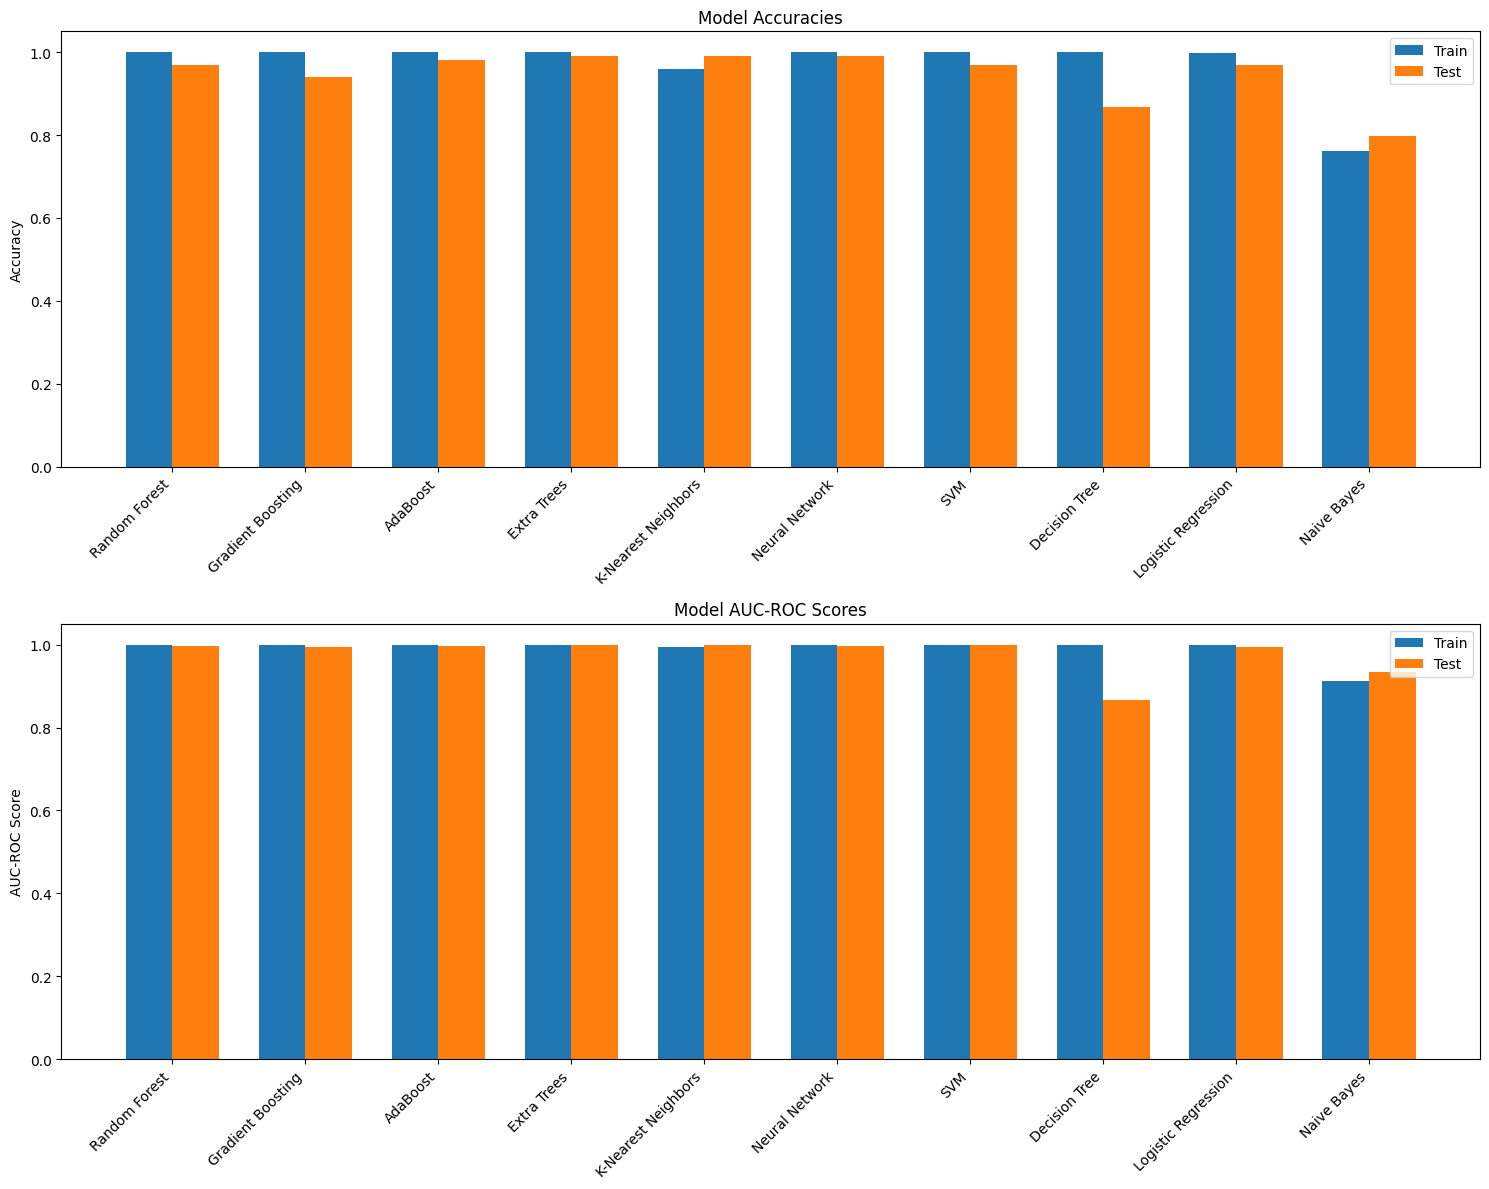


SelectKBest Results:


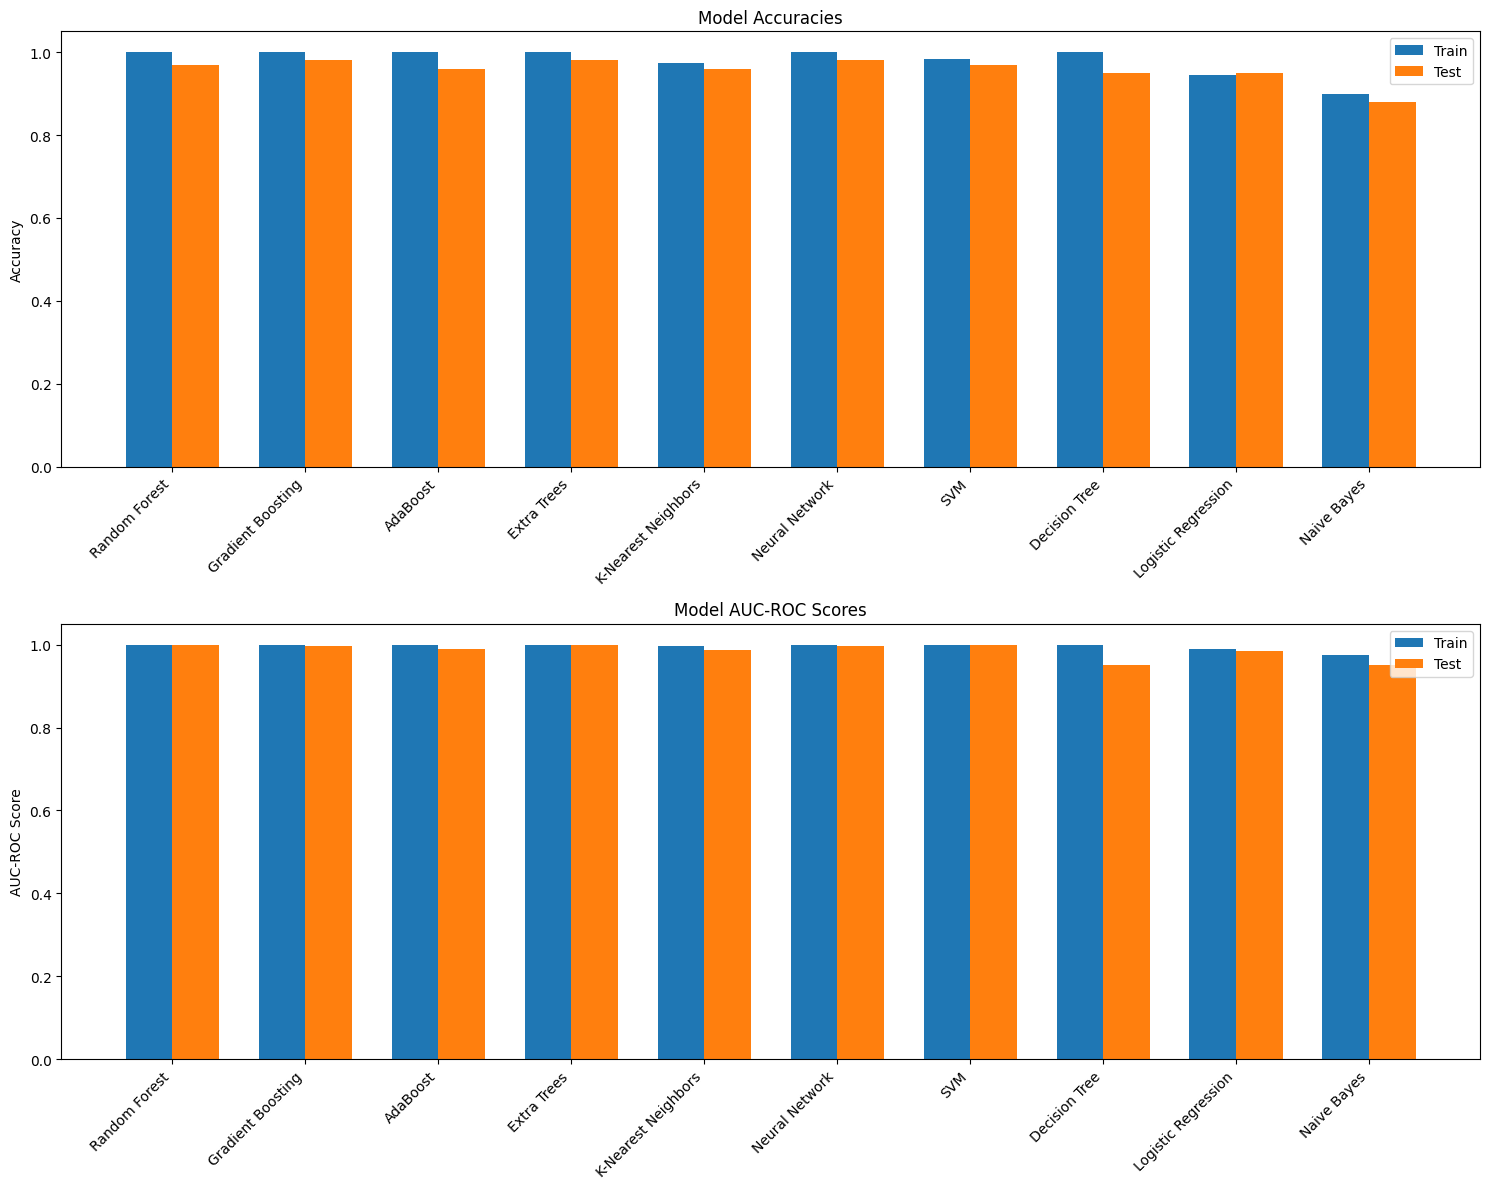

In [30]:
# Cell 7: Visualize results
print("\nPCA Results:")
plot_results(pca_results)

print("\nSelectKBest Results:")
plot_results(select_results)

In [31]:
# Find and print best models
for method_name, results in [("PCA", pca_results), ("SelectKBest", select_results)]:
    print(f"\n{method_name} Best Models:")
    best_train, best_test, smallest_diff = find_best_models(results)
    print(f"Best Training Accuracy: {best_train['model']} ({best_train['accuracy']:.4f})")
    print(f"Best Test Accuracy: {best_test['model']} ({best_test['accuracy']:.4f})")
    print(f"Most Stable Model: {smallest_diff['model']} (Difference: {smallest_diff['diff']:.4f})")


PCA Best Models:
Best Training Accuracy: Random Forest (1.0000)
Best Test Accuracy: Extra Trees (0.9899)
Most Stable Model: Extra Trees (Difference: 0.0101)

SelectKBest Best Models:
Best Training Accuracy: Random Forest (1.0000)
Best Test Accuracy: Gradient Boosting (0.9798)
Most Stable Model: Logistic Regression (Difference: 0.0051)


In [26]:
# Additional cell for cross-validation verification
from sklearn.model_selection import cross_val_score

def verify_no_leakage(pipeline, X, y, cv=5):
    scores = cross_val_score(pipeline, X, y, cv=cv)
    print(f"Cross-validation scores: {scores}")
    print(f"Mean CV score: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

# Verify for each pipeline
for name, pipeline in pca_pipelines.items():
    print(f"\nVerifying {name} with cross-validation:")
    verify_no_leakage(pipeline, X, y)


Verifying Random Forest with cross-validation:
Cross-validation scores: [0.90909091 0.95959596 0.92929293 0.93939394 0.92929293]
Mean CV score: 0.9333 (+/- 0.0328)

Verifying Gradient Boosting with cross-validation:
Cross-validation scores: [0.8989899  0.96969697 0.90909091 0.91919192 0.92929293]
Mean CV score: 0.9253 (+/- 0.0488)

Verifying AdaBoost with cross-validation:
Cross-validation scores: [0.87878788 0.96969697 0.95959596 0.92929293 0.90909091]
Mean CV score: 0.9293 (+/- 0.0664)

Verifying Extra Trees with cross-validation:
Cross-validation scores: [0.92929293 0.95959596 0.93939394 0.95959596 0.94949495]
Mean CV score: 0.9475 (+/- 0.0236)

Verifying K-Nearest Neighbors with cross-validation:
Cross-validation scores: [0.93939394 0.90909091 0.92929293 0.94949495 0.92929293]
Mean CV score: 0.9313 (+/- 0.0268)

Verifying Neural Network with cross-validation:
Cross-validation scores: [0.91919192 0.97979798 0.94949495 0.97979798 0.94949495]
Mean CV score: 0.9556 (+/- 0.0454)

Verif